<a href="https://colab.research.google.com/github/tohays/-DIP392-250ADB007_Anton_Yuksin/blob/main/%D0%AE%D0%BA%D1%81%D1%96%D0%BD_%D0%9A%D0%BE%D0%BD%D1%82%D1%80%D0%BE%D0%BB%D1%8C%D0%BD%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import altair as alt
import plotly.express as px
from vega_datasets import data

In [8]:
# 1. Читання CSV файлу
df_yt = pd.read_csv('Global YouTube Statistics.csv', encoding='latin-1')

# 2. Виведення перших п'яти рядків
df_yt.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [9]:
# 3. Виведення розмірів датасету, перевірка наявності пропусків, дублікатів.
print(f"Розмір датасету: {df_yt.shape}")
print(f"Кількість дублікатів: {df_yt.duplicated().sum()}")
print("\nКількість пропусків у кожному стовпці:")
print(df_yt.isna().sum())

Розмір датасету: (995, 28)
Кількість дублікатів: 0

Кількість пропусків у кожному стовпці:
rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year    

In [10]:
# 4. Якщо є пропуски, заміна типу даних на float і середнє значення за стовпцем.

# Вибираємо тільки числові стовпці
numeric_cols = df_yt.select_dtypes(include=['number']).columns

# Заповнюємо пропуски середнім та перетворюємо на float
df_yt[numeric_cols] = df_yt[numeric_cols].fillna(df_yt[numeric_cols].mean()).astype(float)

# 5. Ще раз перевіряємо кількість пропусків.
print("Пропуски після обробки:")
print(df_yt[numeric_cols].isna().sum())

Пропуски після обробки:
rank                                       0
subscribers                                0
video views                                0
uploads                                    0
video_views_rank                           0
country_rank                               0
channel_type_rank                          0
video_views_for_the_last_30_days           0
lowest_monthly_earnings                    0
highest_monthly_earnings                   0
lowest_yearly_earnings                     0
highest_yearly_earnings                    0
subscribers_for_last_30_days               0
created_year                               0
created_date                               0
Gross tertiary education enrollment (%)    0
Population                                 0
Unemployment rate                          0
Urban_population                           0
Latitude                                   0
Longitude                                  0
dtype: int64


In [11]:
# 6. Перевірка, скільки унікальних країн представлено у колонці "Country"
unique_countries = df_yt['Country'].nunique()
print(f"Кількість унікальних країн: {unique_countries}")

# 8. Визначення максимальної, мінімальної, середньої кількості переглядів
views_stats = {
    'Максимум': df_yt['video views'].max(),
    'Мінімум': df_yt['video views'].min(),
    'Середнє': df_yt['video views'].mean()
}
print("\nСтатистика переглядів:")
for k, v in views_stats.items():
    print(f"{k}: {v:,.0f}")

Кількість унікальних країн: 49

Статистика переглядів:
Максимум: 228,000,000,000
Мінімум: 0
Середнє: 11,039,537,052


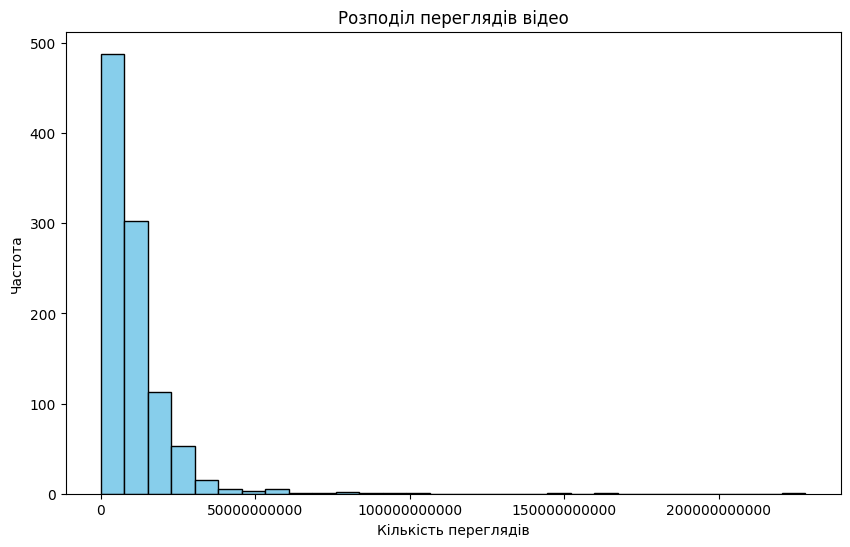

In [12]:
# 7. Побудова діаграми розподілу переглядів (kind='hist')
plt.figure(figsize=(10, 6))
df_yt['video views'].plot(kind='hist', bins=30, color='skyblue', edgecolor='black')
plt.title('Розподіл переглядів відео')
plt.xlabel('Кількість переглядів')
plt.ylabel('Частота')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

In [13]:
# 9. Знаходження країни, де найбільше відео було завантажено на YouTube
top_country = df_yt.groupby('Country')['uploads'].sum().idxmax()
print(f"Країна з найбільшою кількістю завантажень: {top_country}")

# 10. Знаходження відео (назви каналу/Title) з найбільшою та найменшою кількістю завантажень uploads.
max_uploads_idx = df_yt['uploads'].idxmax()
min_uploads_idx = df_yt['uploads'].idxmin()

print(f"\nНайбільша кількість завантажень: {df_yt.loc[max_uploads_idx, 'Title']} ({df_yt.loc[max_uploads_idx, 'uploads']})")
print(f"Найменша кількість завантажень: {df_yt.loc[min_uploads_idx, 'Title']} ({df_yt.loc[min_uploads_idx, 'uploads']})")

Країна з найбільшою кількістю завантажень: India

Найбільша кількість завантажень: ABP NEWS (301308.0)
Найменша кількість завантажень: Music (0.0)


In [14]:
#2 завдання
# Завантаження файлу
df_shop = pd.read_csv('shopping_trends.csv')

# Перевірка розміру, пропусків та типів стовпців
print(f"Розмір таблиці: {df_shop.shape}")
print("\nПропуски:")
print(df_shop.isna().sum())
print("\nТипи стовпців:")
print(df_shop.dtypes)

Розмір таблиці: (3900, 19)

Пропуски:
Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

Типи стовпців:
Customer ID                   int64
Age                           int64
Gender                       object
Item Purchased               object
Category                     object
Purchase Amount (USD)         int64
Location                     object
Size                         object
Color                        object
Season                       object
Rev

In [15]:
# Зміна прописних букв на строчні та пробілів на підкреслення
df_shop.columns = [c.lower().replace(' ', '_') for c in df_shop.columns]

# Виведення оновлених назв
print("Оновлені назви стовпців:")
print(df_shop.columns.tolist())

Оновлені назви стовпців:
['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount_(usd)', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'payment_method', 'shipping_type', 'discount_applied', 'promo_code_used', 'previous_purchases', 'preferred_payment_method', 'frequency_of_purchases']


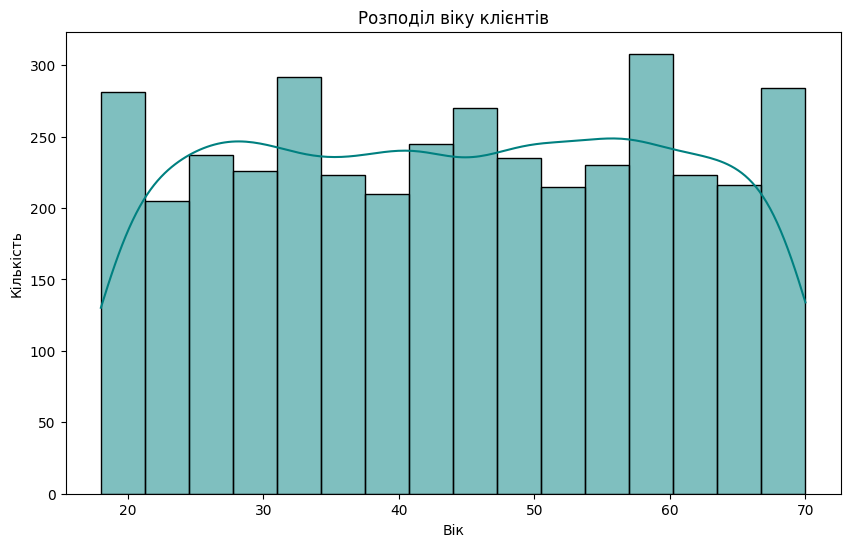

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df_shop['age'], kde=True, color='teal')
plt.title('Розподіл віку клієнтів')
plt.xlabel('Вік')
plt.ylabel('Кількість')
plt.show()

/tmp/ipykernel_3046/894197480.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_shop, y='item_purchased', order=df_shop['item_purchased'].value_counts().index, palette='viridis')


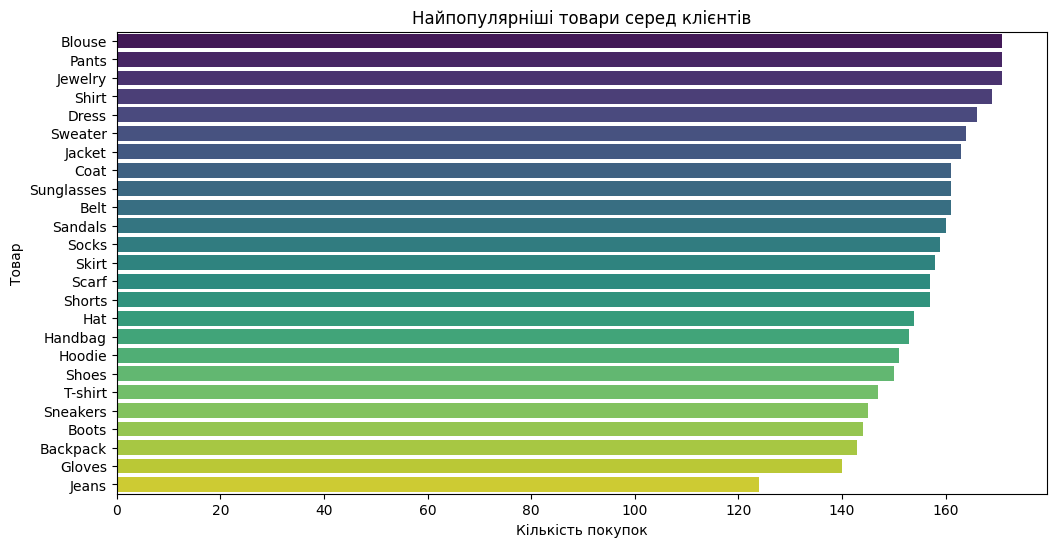

In [17]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_shop, y='item_purchased', order=df_shop['item_purchased'].value_counts().index, palette='viridis')
plt.title('Найпопулярніші товари серед клієнтів')
plt.xlabel('Кількість покупок')
plt.ylabel('Товар')
plt.show()

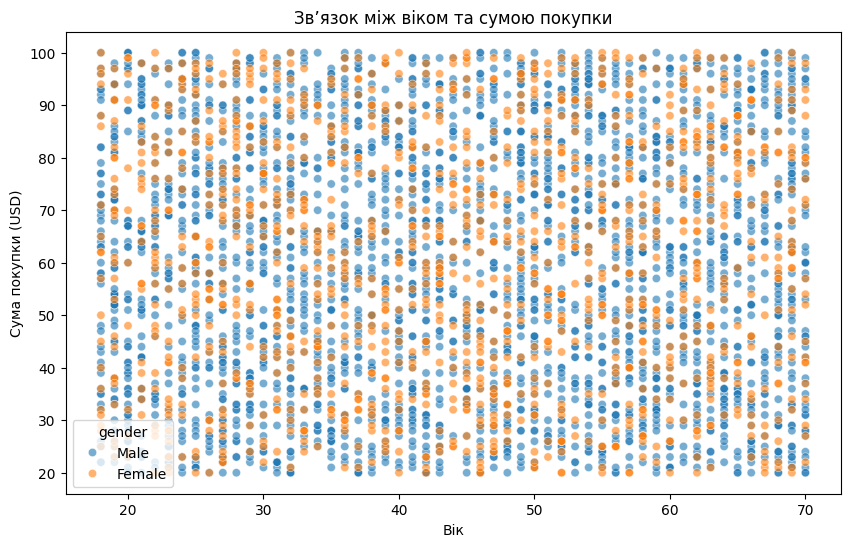

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_shop, x='age', y='purchase_amount_(usd)', hue='gender', alpha=0.6)
plt.title('Зв’язок між віком та сумою покупки')
plt.xlabel('Вік')
plt.ylabel('Сума покупки (USD)')
plt.show()

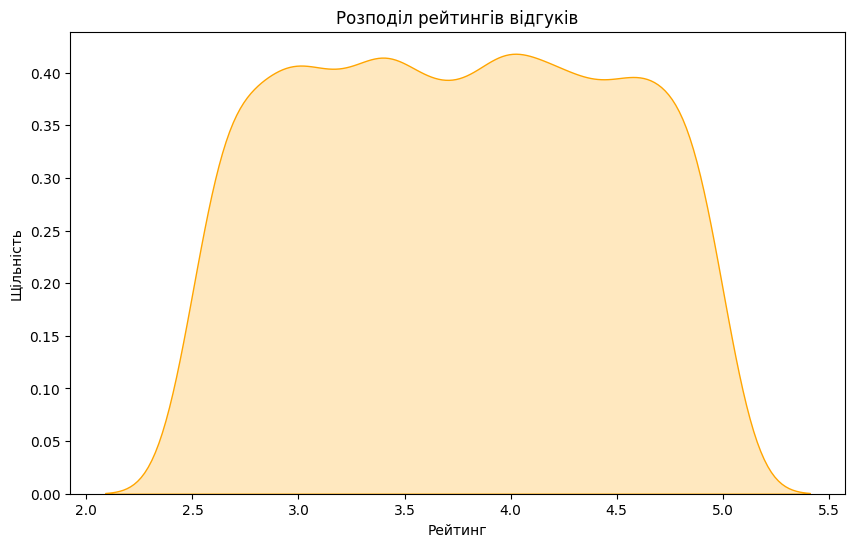

In [19]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_shop['review_rating'], fill=True, color='orange')
plt.title('Розподіл рейтингів відгуків')
plt.xlabel('Рейтинг')
plt.ylabel('Щільність')
plt.show()

/tmp/ipykernel_3046/3952512189.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_shop, x='gender', y='purchase_amount_(usd)', palette='pastel')


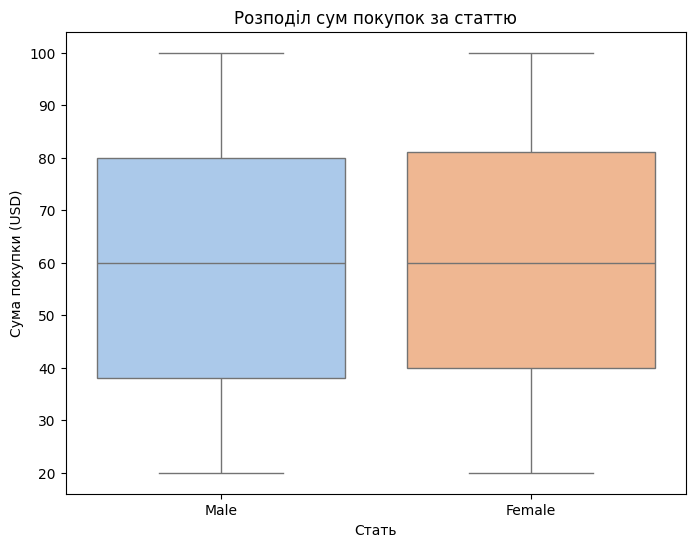

In [20]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_shop, x='gender', y='purchase_amount_(usd)', palette='pastel')
plt.title('Розподіл сум покупок за статтю')
plt.xlabel('Стать')
plt.ylabel('Сума покупки (USD)')
plt.show()

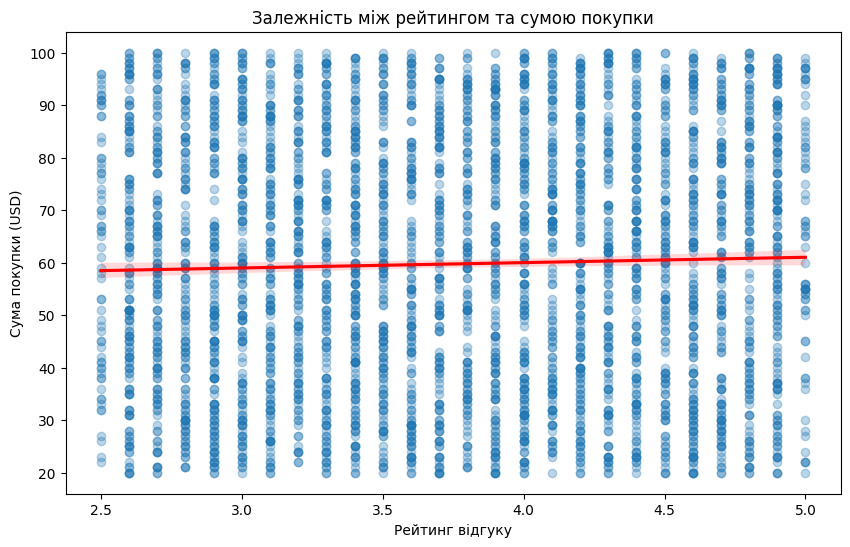

In [21]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_shop, x='review_rating', y='purchase_amount_(usd)', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Залежність між рейтингом та сумою покупки')
plt.xlabel('Рейтинг відгуку')
plt.ylabel('Сума покупки (USD)')
plt.show()

In [22]:
# 3 завдання
# Завантаження даних про пшеницю
wheat = data.wheat()

# 1. Створюємо базовий графік (стовпчики)
bars = alt.Chart(wheat).mark_bar().encode(
    x=alt.X('yield:Q', title='Врожайність пшениці'),
    y=alt.Y('year:O', title='Рік') # 'O' означає ординальний (категоріальний) тип для років
)

# 2. Створюємо мітки з текстом
text = bars.mark_text(
    align='left',
    baseline='middle',
    dx=3  # зсув тексту вправо від стовпчика
).encode(
    text='yield:Q'
)

# Об'єднуємо шари
chart1 = (bars + text).properties(
    title='Врожайність пшениці за роками',
    width=600
)

chart1.display()

alt.LayerChart(...)

In [23]:
# Завантажуємо дані про електроенергію
iowa_env = data.iowa_electricity()

# Створюємо діаграму з областями (Area Chart) або стовпчиками (Bar Chart)
# У завданні вказано "багатошарова діаграма" та "прозорість стовпців", тому використаємо mark_bar
chart2 = alt.Chart(iowa_env).mark_bar(opacity=0.7).encode(
    x=alt.X('year:T', title='Рік'), # 'T' для часових даних
    y=alt.Y('net_generation:Q', title='Чисте виробництво електроенергії'),
    color=alt.Color('source:N', title='Джерело енергії') # 'N' для номінальних назв
).properties(
    title='Виробництво електроенергії в Айові за джерелами',
    width=700,
    height=400
)

chart2.display()

alt.Chart(...)

In [24]:
# Завантажуємо дані ірисів
df_iris = px.data.iris()

# Створюємо точковий графік
fig = px.scatter(
    df_iris,
    x="sepal_width",
    y="sepal_length",
    size="petal_length", # Розмір точки залежить від довжини пелюстки
    color="species",     # Колір залежить від виду
    hover_data=["petal_width"], # Додаткові дані при наведенні
    title="Аналіз параметрів ірисів (Sepal Width vs Length)"
)

# Вирівнювання заголовка за центром
fig.update_layout(title_x=0.5)

fig.show()